<a href="https://colab.research.google.com/github/charlesdgburns/ring_attractors_and_rnns/blob/main/choices_and_climate_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Choices and climate change

This is a story about physics and maths being unified across scales - from the small changes in activity of neurons in brains to the large changes in ocean currents on earth. In some ways, this is also the story of me choosing to shift my focus from neuroscience to climate change. For you, I hope it's an interesting read about:

1. **How neurons give rise to decisions**, and
2. **When climate change will be irreversible**.

Here's **the gist**: both our brains and our climate rely on stable patterns of a system which is often chaotic. In particular those stable states which are *attractors*, points that the system is pulled towards with minimal external input. The key point is that these stable states can take different shapes. In some cases, for example if there are exactly two attractors, this introduces a *tipping point*. It turns out, our neurons cross such a tipping point every time we choose left over right. We are also crossing such tipping points as we continue to emit carbon into our atmosphere. These tipping points keep apart the stable states, making it harder to switch from one to the other. For the brain this helps us separate actions like left and right, while for the climate this makes some changes very hard to reverse.

But how do we know the shape of the dynamical landscape? In some cases it could also be continuous, with a whole series of stable states that the system can move through, or have a single attractor that moves as the system changes. How do we identify the dynamical systems underlying our decisions or the climate?

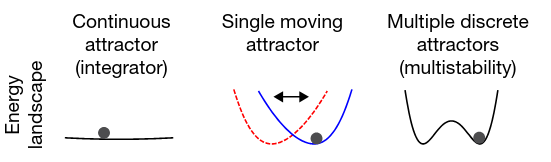


---


Let's **degist**: diving into the nitty gritty and answering the questions that naturally follow the big picture. We will take a closer look at two scientific papers which helped paint the picture for me:

1. **Discrete attractor dynamics underlies persistent activity in the frontal cortex** [(Inagaki et al., 2019)](https://drive.google.com/file/d/1zpUTz8pS4QDxQTPQhll0x70iFmCavl9V/view)
2. **Warning of a forthcoming collapse of the atlantic meridional overturning circulation** [(Ditlevsen & Ditlevsen, 2023)](https://www.nature.com/articles/s41467-023-39810-w).


# How neurons give rise to decisions

This story started taking shape when I started studyng decision-making from the perspective of computational neuroscience. We know that our nervous system acts as a result of thousands (millions of thousands) of neurons that connect and talk to each other through 'spikes', short bursts of electrical activity going from one neuron out to others. But how do these millions of neurons coordinate their activity to make complex movements, or even simple decisions?

Consider a really simple delayed response task: you hear a tone, wait 2 seconds, then choose left or right. When the tone is low-pitched, you'll get a reward on the left, and when the tone is high-pitched you'll get a reward on the right. When did you make your choice? If you know the task well, you might have made up your mind as soon as you recognised the pitch of the tone. But during those two seconds of waiting, your neurons must somehow store the information of the cue, keeping a memory, before you act and make a choice. How?

The answer lies in attractor dynamics, stable patterns of activity in the dynamical system of many neurons. In this case, a stable pattern of activity holds information as a memory which lets us make an informed choice. What exactly do I mean by pattern? Ironically, we can gain a lot of understanding of these thousands of neurons from modelling them as just a few 'populations'. One population is active whenever you choose to go left, the other population is active whenever you choose right. We can describe the activity of the two populations as the 'patterns' $[1,0]$ and $[0,1]$, but also $[0,0]$ if none are active and $[1,1]$ if both are.

This is what Hidehiko Inagaki saw when recording the neurons of mice doing this simple delayed response task - neurons consistently had one stable pattern of activity when mice chose to go left and another stable pattern when mice chose to go right. Each decision corresponds to a stable pattern of activity! The main question then is how do neurons go from one stable pattern to another - what is the dynamical landscape underlying decsions?





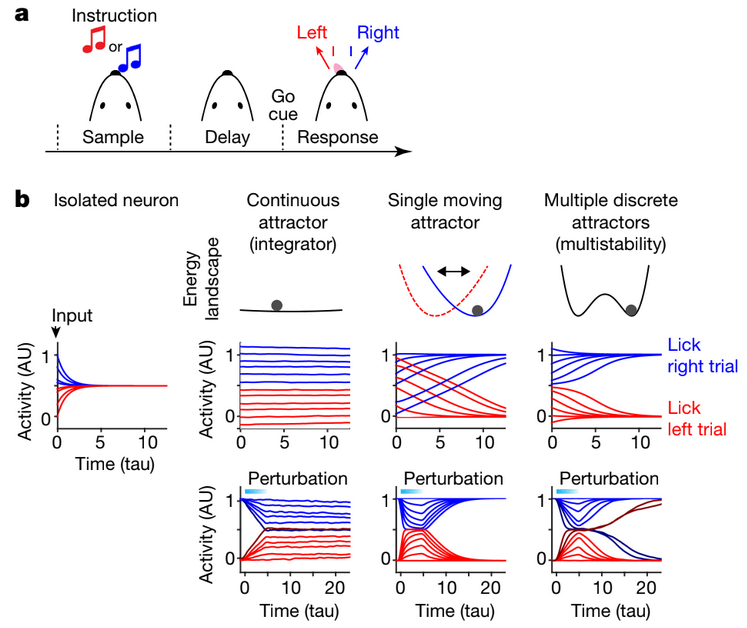

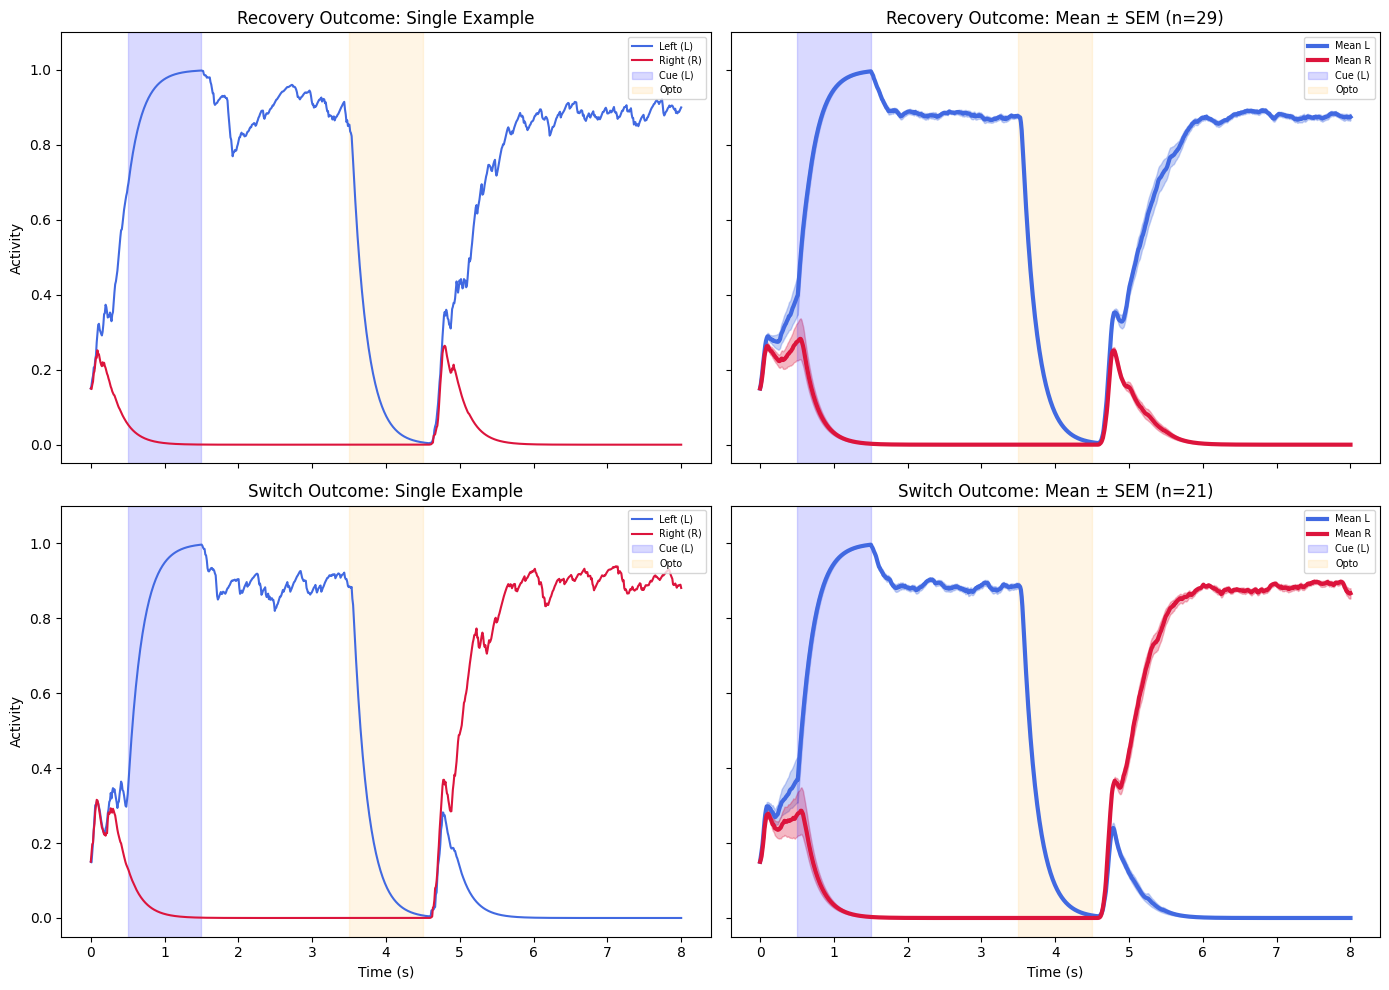

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
p = {
    'T': 8.0, 'dt': 0.01,
    'tau_e': 0.2, 'tau_i': 0.05,
    'noise_amp': 0.1,
    'baseline_e': 0.4, 'baseline_i': 0.1,
    'sigmoid_gain': 10,
    'sigmoid_thresh_e': 0.5,
    'sigmoid_thresh_i': 0.6,
    # Timing & Magnitudes
    'cue_start': 0.5, 'cue_end': 1.5, 'cue_mag': 1.2,
    'opto_start': 3.5, 'opto_end': 4.5, 'opto_mag': 5.0
}

# --- 2. Fully Connected Weight Matrix (L, R, I) ---
# No zeros: self-excitation, cross-talk, and recurrent inhibition
W = np.array([
    [ 2.2,  0.2, -2.2], # L
    [ 0.2,  2.2, -2.2], # R
    [ 1.1,  1.1, -0.5]  # I
])

def f(x, thresh, gain):
    return 1 / (1 + np.exp(-(x - thresh) * gain))

def run_trial(params):
    steps = int(params['T'] / params['dt'])
    r = np.zeros((3, steps))
    r[:, 0] = 0.15

    for t in range(steps - 1):
        t_sec = t * params['dt']
        ext_in = np.array([params['baseline_e'], params['baseline_e'], params['baseline_i']])

        if params['cue_start'] < t_sec < params['cue_end']:
            ext_in[0] += params['cue_mag']
        if params['opto_start'] < t_sec < params['opto_end']:
            ext_in[2] += params['opto_mag']

        net = np.dot(W, r[:, t]) + ext_in + np.random.normal(0, params['noise_amp'], 3)

        r[0, t+1] = r[0, t] + (-r[0, t] + f(net[0], params['sigmoid_thresh_e'], params['sigmoid_gain'])) / (params['tau_e']/params['dt'])
        r[1, t+1] = r[1, t] + (-r[1, t] + f(net[1], params['sigmoid_thresh_e'], params['sigmoid_gain'])) / (params['tau_e']/params['dt'])
        r[2, t+1] = r[2, t] + (-r[2, t] + f(net[2], params['sigmoid_thresh_i'], params['sigmoid_gain'])) / (params['tau_i']/params['dt'])
        r[:, t+1] = np.clip(r[:, t+1], 0, 1)
    return r

# --- 3. Run Simulation ---
n_trials = 50
trials = np.array([run_trial(p) for _ in range(n_trials)])
t_axis = np.linspace(0, p['T'], int(p['T']/p['dt']))

# Categorize into Recovery vs Switch
rec_idx = np.where(trials[:, 0, -1] > trials[:, 1, -1])[0]
swi_idx = np.where(trials[:, 1, -1] > trials[:, 0, -1])[0]

# --- 4. Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

def plot_outcome(row, indices, title):
    if len(indices) == 0: return
    data = trials[indices]

    # Left Column: Single Example
    axes[row, 0].plot(t_axis, data[0, 0], color='royalblue', lw=1.5, label='Left (L)')
    axes[row, 0].plot(t_axis, data[0, 1], color='crimson', lw=1.5, label='Right (R)')
    axes[row, 0].set_title(f"{title}: Single Example")

    # Right Column: Mean + SEM
    mu = np.mean(data, axis=0)
    sem = np.std(data, axis=0) / np.sqrt(len(data))

    axes[row, 1].plot(t_axis, mu[0], color='royalblue', lw=3, label='Mean L')
    axes[row, 1].fill_between(t_axis, mu[0]-sem[0], mu[0]+sem[0], color='royalblue', alpha=0.3)
    axes[row, 1].plot(t_axis, mu[1], color='crimson', lw=3, label='Mean R')
    axes[row, 1].fill_between(t_axis, mu[1]-sem[1], mu[1]+sem[1], color='crimson', alpha=0.3)
    axes[row, 1].set_title(f"{title}: Mean ± SEM (n={len(indices)})")

    # Formatting for both columns in the row
    for col in [0, 1]:
        axes[row, col].axvspan(p['cue_start'], p['cue_end'], color='blue', alpha=0.15, label='Cue (L)')
        axes[row, col].axvspan(p['opto_start'], p['opto_end'], color='orange', alpha=0.1, label='Opto')
        axes[row, col].legend(loc='upper right', fontsize='x-small')
        axes[row, col].set_ylim(-0.05, 1.1)

plot_outcome(0, rec_idx, "Recovery Outcome")
plot_outcome(1, swi_idx, "Switch Outcome")

axes[1, 0].set_xlabel("Time (s)"); axes[1, 1].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Activity"); axes[1, 0].set_ylabel("Activity")

plt.tight_layout()
plt.show()

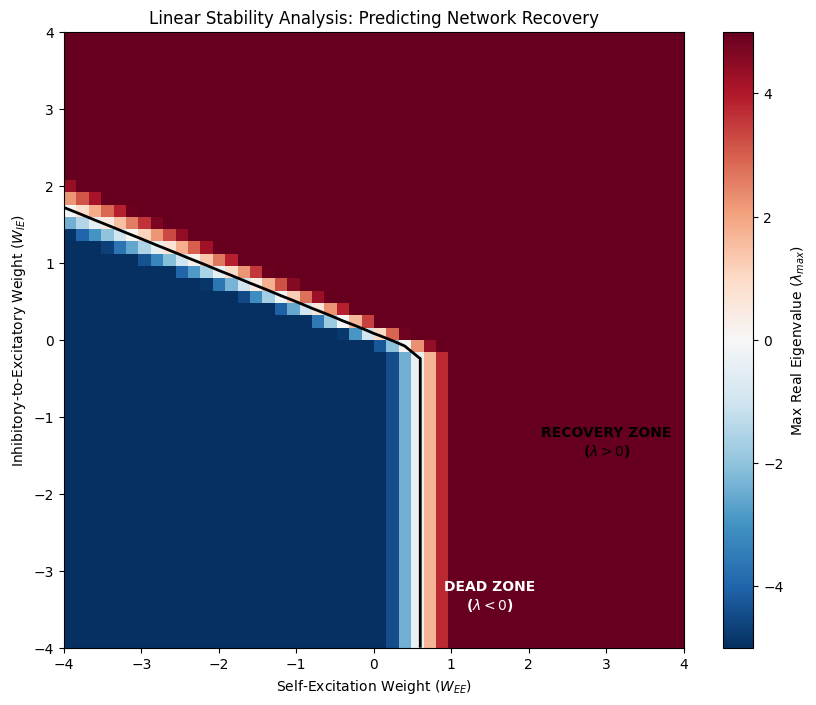

In [ ]:
## jacobian linear stability analysis

import numpy as np
import matplotlib.pyplot as plt

# --- Setup Parameters for the Jacobian ---
p = {
    'tau_e': 0.2,
    'tau_i': 0.05,
    'sigmoid_gain': 10,
    'baseline_e': 0.4,
    'sigmoid_thresh_e': 0.5
}

# Range of weights to test
wee_range = np.linspace(-4.0, 4.0, 50)  # Self-excitation (L->L, R->R)
wie_range = np.linspace(-4.0, 4.0, 50) # Inhibition (I->L, I->R)

# Matrix to store the max eigenvalue
max_eig_matrix = np.zeros((len(wie_range), len(wee_range)))

def get_max_eig(wee, wie, params):
    # W = [L, R, I]
    # We keep cross-talk and recurrent-I constant for this sweep
    W = np.array([
        [wee,  0.2,  wie],
        [0.2,  wee,  wie],
        [1.1,  1.1, -0.5]
    ])

    # Calculate Gain (slope) of sigmoid at the 'neutral' threshold
    # Derivative of 1/(1+exp(-g(x-th))) is g * f(x) * (1-f(x))
    # At x=threshold, f(x)=0.5, so slope = gain * 0.25
    g = params['sigmoid_gain'] * 0.25

    # Construct Jacobian J = (1/tau) * (-I + G*W)
    # This represents the linear dynamics near the 'tipping point'
    inv_tau = np.diag([1/params['tau_e'], 1/params['tau_e'], 1/params['tau_i']])
    G = np.diag([g, g, g])

    J = -inv_tau + (inv_tau @ G @ W)

    # Return the real part of the largest eigenvalue
    return np.max(np.real(np.linalg.eigvals(J)))

# Run the sweep
for i, wie in enumerate(wie_range):
    for j, wee in enumerate(wee_range):
        max_eig_matrix[i, j] = get_max_eig(wee, wie, p)

# --- Plotting ---
plt.figure(figsize=(10, 8))
# Use a diverging colormap: Red = Unstable (Recovery), Blue = Stable (Dead)
im = plt.imshow(max_eig_matrix, extent=[wee_range[0], wee_range[-1], wie_range[0], wie_range[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=-5, vmax=5)

plt.contour(wee_range, wie_range, max_eig_matrix, levels=[0], colors='black', linewidths=2)
# Add 'r' before the strings containing backslashes
plt.colorbar(im, label=r'Max Real Eigenvalue ($\lambda_{max}$)')
plt.text(3.0, -1.5, r"RECOVERY ZONE" + "\n" + r"($\lambda > 0$)", color='black', fontweight='bold', ha='center')
plt.text(1.5, -3.5, r"DEAD ZONE" + "\n" + r"($\lambda < 0$)", color='white', fontweight='bold', ha='center')

plt.xlabel('Self-Excitation Weight ($W_{EE}$)')
plt.ylabel('Inhibitory-to-Excitatory Weight ($W_{IE}$)')
plt.title('Linear Stability Analysis: Predicting Network Recovery')
plt.show()

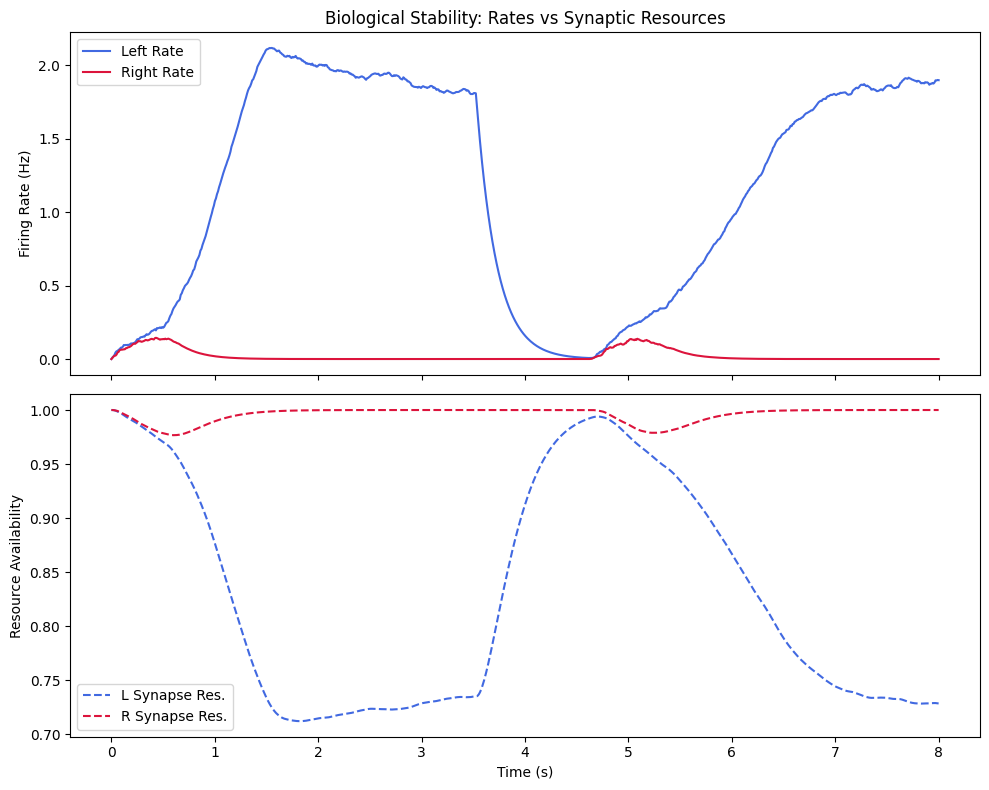

Calculated Wee for 1.0Hz stability: 1.056


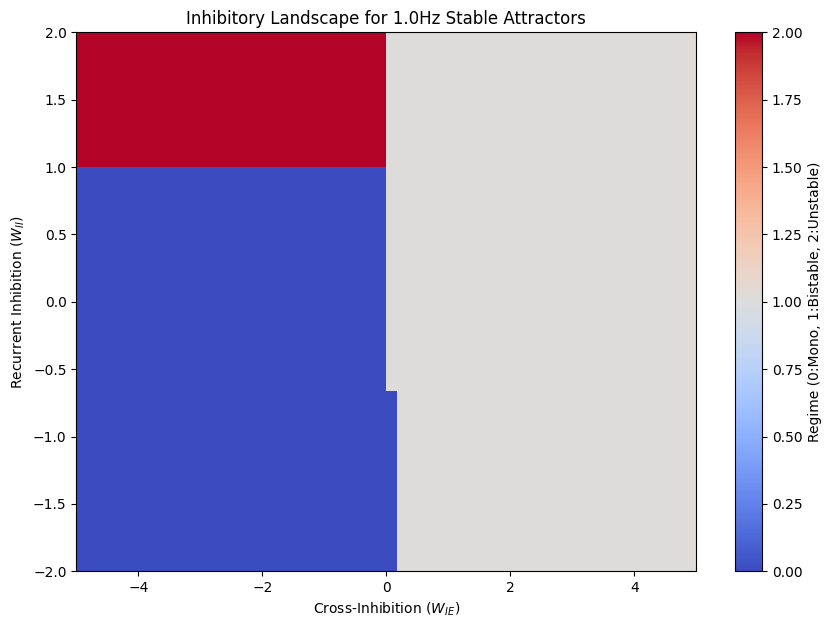

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Fixed Biological Constraints ---
p = {
    'tau_e': 0.2, 'tau_i': 0.05, 'tau_rec': 0.8,
    'U': 0.4, 'target_r': 1.0, 'baseline': 0.2, 'k': 0.1
}

def softplus(x, k=0.1):
    return k * np.log(1 + np.exp(x/k))

# --- 2. Analytic "Scratch" Calculation ---
# Find the Wee that supports 1Hz for the given U
# x_ss is synaptic availability at 1Hz
x_ss = 1 / (1 + p['U'] * p['tau_rec'] * p['target_r'])

# To find Wee, we invert the Softplus at the target rate
# r = softplus(net) -> net = k * log(exp(r/k) - 1)
required_net = p['k'] * np.log(np.exp(p['target_r']/p['k']) - 1)
# required_net = Wee * x_ss * target_r + baseline
wee_fixed = (required_net - p['baseline']) / (x_ss * p['target_r'])

print(f"Calculated Wee for {p['target_r']}Hz stability: {wee_fixed:.3f}")

# --- 3. Sweep Inhibitory Weights (Wie and Wii) ---
wie_range = np.linspace(-5.0, 5.0, 60) # I -> E
wii_range = np.linspace(-2.0, 2.0, 60) # I -> I (recurrent inhibition)

stability_map = np.zeros((len(wii_range), len(wie_range)))

for i, wii in enumerate(wii_range):
    for j, wie in enumerate(wie_range):
        # Weight Matrix: [L, R, I]
        # We assume L->I and R->I (Wei) are fixed at 1.0 for the sweep
        W = np.array([
            [wee_fixed, 0.1,      wie],
            [0.1,      wee_fixed, wie],
            [1.0,      1.0,       wii]
        ])

        # Calculate Effective Gain (G) at the 1Hz operating point
        # Derivative of softplus is the sigmoid: 1 / (1 + exp(-x/k))
        gain_e = 1 / (1 + np.exp(-required_net/p['k']))
        # For simplicity, assume I unit is at 1Hz gain too
        G = np.diag([gain_e, gain_e, gain_e])

        # Jacobian with Synaptic Scaling
        # Note: A full Jacobian would include dx/dt, but the 'Fast' dynamics
        # are dominated by the Rate Jacobian J = (1/tau)(-I + G*W_effective)
        W_eff = W.copy()
        W_eff[0,0] *= x_ss; W_eff[1,1] *= x_ss

        inv_tau = np.diag([1/p['tau_e'], 1/p['tau_e'], 1/p['tau_i']])
        J = -np.eye(3)*inv_tau + (inv_tau @ G @ W_eff)

        eigs = np.linalg.eigvals(J)
        real_eigs = np.sort(np.real(eigs))

        # Categorize
        if np.all(real_eigs < 0):
            stability_map[i, j] = 0 # Mono-stable (Symmetric 1Hz is stable)
        elif real_eigs[-1] > 0 and real_eigs[-2] < 0:
            stability_map[i, j] = 1 # Bistable (Winner-Take-All)
        else:
            stability_map[i, j] = 2 # Unstable/Oscillatory

# --- 4. Plotting ---
plt.figure(figsize=(10, 7))
plt.imshow(stability_map, extent=[wie_range[0], wie_range[-1], wii_range[0], wii_range[-1]],
           origin='lower', aspect='auto', cmap='coolwarm')

plt.colorbar(label='Regime (0:Mono, 1:Bistable, 2:Unstable)')
plt.xlabel('Cross-Inhibition ($W_{IE}$)')
plt.ylabel('Recurrent Inhibition ($W_{II}$)')
plt.title(f'Inhibitory Landscape for {p["target_r"]}Hz Stable Attractors')
plt.show()

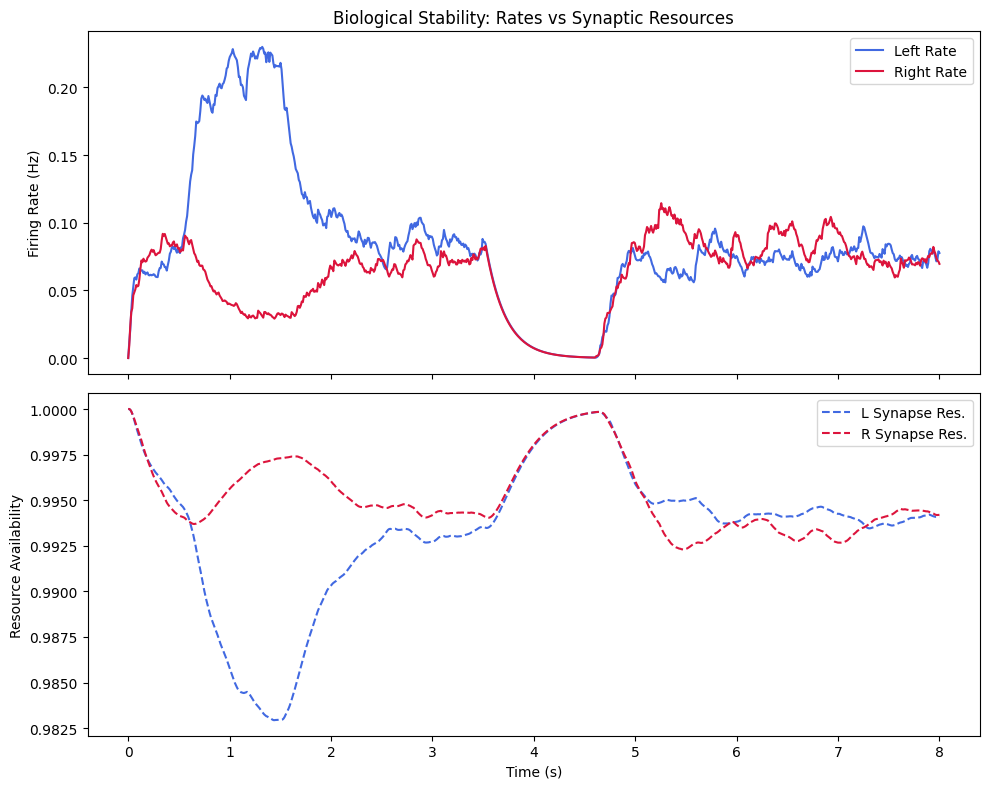

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Updated Parameters for Synaptic Stability ---
p = {
    'T': 8.0, 'dt': 0.01,
    'tau_e': 0.2, 'tau_i': 0.05,
    'tau_rec': 0.2,      # Recovery time of synapses (s)
    'U_depress': 0.99 ,    # Fraction of resources used per "spike"
    'noise_amp': 0.1,
    'baseline_e': 0.2,   # Lower baseline since Softplus is sensitive
    'softplus_k': 0.1,   # Curvature of the Softplus
    'cue_start': 0.5, 'cue_end': 1.5, 'cue_mag': 0.2,
    'opto_start': 3.5, 'opto_end': 4.5, 'opto_mag': 5.0
}

W = np.array([
    [2.5, 0.2, -1.5], # Higher Wee needed to overcome depression
    [0.2, 2.5, -1.5],
    [1.2, 1.2, -0.5]
])

def softplus(x, k=0.1):
    # g(x) = k * log(1 + exp(x/k)) -> Smooth version of ReLU
    return k * np.log(1 + np.exp(x/k))

def run_bio_trial(params):
    steps = int(params['T'] / params['dt'])
    r = np.zeros((3, steps))
    x_syn = np.ones((2, steps)) # Synaptic resources for L and R

    for t in range(steps - 1):
        t_sec = t * params['dt']
        ext_in = np.array([params['baseline_e'], params['baseline_e'], 0.1])

        if params['cue_start'] < t_sec < params['cue_end']: ext_in[0] += params['cue_mag']
        if params['opto_start'] < t_sec < params['opto_end']: ext_in[2] += params['opto_mag']

        # Effective Excitatory Output = Rate * Synaptic Resources
        eff_r = np.array([r[0,t]*x_syn[0,t], r[1,t]*x_syn[1,t], r[2,t]])

        net = np.dot(W, eff_r) + ext_in + np.random.normal(0, params['noise_amp'], 3)

        # 1. Update Rates (Softplus instead of Sigmoid)
        r[0, t+1] = r[0, t] + (-r[0, t] + softplus(net[0], params['softplus_k'])) / (params['tau_e']/params['dt'])
        r[1, t+1] = r[1, t] + (-r[1, t] + softplus(net[1], params['softplus_k'])) / (params['tau_e']/params['dt'])
        r[2, t+1] = r[2, t] + (-r[2, t] + softplus(net[2], params['softplus_k'])) / (params['tau_i']/params['dt'])

        # 2. Update Synaptic Depression for L and R
        for i in range(2):
            dx = (1 - x_syn[i, t]) / params['tau_rec'] - params['U_depress'] * r[i, t] * x_syn[i, t]
            x_syn[i, t+1] = x_syn[i, t] + dx * params['dt']

        r[:, t+1] = np.clip(r[:, t+1], 0, 5) # Biological clip (e.g. 50Hz)
    return r, x_syn

# --- Simulation ---
trial_r, trial_x = run_bio_trial(p)
t_axis = np.linspace(0, p['T'], len(trial_r[0]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_axis, trial_r[0], color='royalblue', label='Left Rate')
ax1.plot(t_axis, trial_r[1], color='crimson', label='Right Rate')
ax1.set_ylabel("Firing Rate (Hz)")
ax1.legend()
ax1.set_title("Biological Stability: Rates vs Synaptic Resources")

ax2.plot(t_axis, trial_x[0], color='royalblue', ls='--', label='L Synapse Res.')
ax2.plot(t_axis, trial_x[1], color='crimson', ls='--', label='R Synapse Res.')
ax2.set_ylabel("Resource Availability")
ax2.set_xlabel("Time (s)")
ax2.legend()

plt.tight_layout()
plt.show()

# When climate change will be irreversible

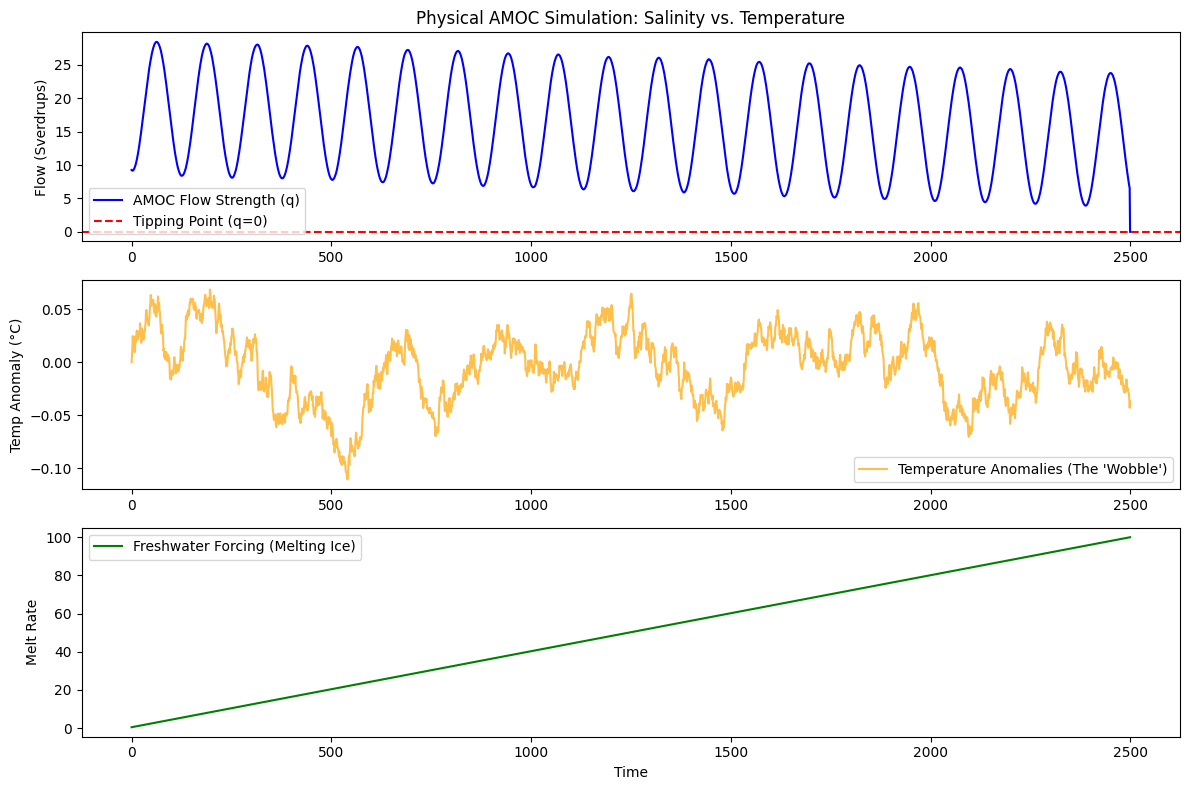

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Parameters ---
steps = 2500
dt = 0.1
time = np.arange(steps)

# Constants
alpha = 2.0        # Thermal sensitivity
beta = 1.5         # Salinity sensitivity
recovery_k = 0.1   # How fast the system "wants" to be at equilibrium
sigma = 0.05       # Weather noise

# Inputs
T_seasonal = 5.0 * np.cos(0.05 * time)  # Fast Seasonal Cycle
T_global_warm = 0.001 * time            # Slow Global Warming Trend

# The "Forcing": Freshwater melt increasing over time
F_melt = np.linspace(0.5, 100, steps)   # The "Crank" being turned

# --- 2. Simulation ---
T_anomaly = np.zeros(steps)
S_anomaly = np.zeros(steps)
q = np.zeros(steps)  # Flow strength

for t in range(steps - 1):
    # Current Flow Strength (Stommel-inspired)
    # Flow = (Thermal difference) - (Salinity difference)
    # We add the seasonal and global T to the North Box
    q[t] = alpha * (10 - (T_global_warm[t] + T_seasonal[t] + T_anomaly[t])) - beta * (S_anomaly[t] + F_melt[t])

    # If flow is positive, it pulls salt from the south (Self-reinforcing)
    # If flow slows, salt accumulates less, but freshwater (F_melt) dominates
    dS = (-S_anomaly[t] + (0.5 if q[t] > 0.5 else 0) - F_melt[t]) * dt

    # Temperature tries to return to seasonal "normal" but is pushed by noise
    dT = (-recovery_k * T_anomaly[t] + np.random.normal(0, sigma)) * dt

    S_anomaly[t+1] = S_anomaly[t] + dS
    T_anomaly[t+1] = T_anomaly[t] + dT

# --- 3. Visualization ---
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(q, color='blue', label="AMOC Flow Strength (q)")
plt.axhline(0, color='red', linestyle='--', label="Tipping Point (q=0)")
plt.title("Physical AMOC Simulation: Salinity vs. Temperature")
plt.ylabel("Flow (Sverdrups)")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(T_anomaly, color='orange', alpha=0.7, label="Temperature Anomalies (The 'Wobble')")
plt.ylabel("Temp Anomaly (°C)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(F_melt, color='green', label="Freshwater Forcing (Melting Ice)")
plt.ylabel("Melt Rate")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
sst_url = "https://climatereanalyzer.org/clim/sst_daily/json/oisst2.1_natlan1_sst_day.json"
sst_raw = pd.read_json(sst_url)

# Flatten and filter for 2004-2020
sst_flat = []
for row in sst_raw.iterrows():
    if 2004 <= int(row['name']) <= 2020:
        sst_flat.extend(row['data'])

TypeError: tuple indices must be integers or slices, not str

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np

# 1. Define the Subpolar Gyre (SPG) Box
# Latitude: 45N to 65N | Longitude: 300E to 350E (60W to 10W)
lat_bounds = [45, 65]
lon_bounds = [300, 350]

def get_real_climate_data(year=2023):
    # OPeNDAP URL for NOAA High-Res Daily SST
    sst_url = f"https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.day.mean.{year}.v2.nc"

    # OPeNDAP URL for Global Mean Temp (GISTEMP monthly)
    gmt_url = "https://psl.noaa.gov/thredds/dodsC/Datasets/gistemp/combined/250km/air.2x2.mnmean.nc"

    print(f"Connecting to NOAA servers for {year} data...")

    # Load SST and extract the Subpolar Gyre box
    ds_sst = xr.open_dataset(sst_url)
    spg_sst = ds_sst.sst.sel(lat=slice(*lat_bounds), lon=slice(*lon_bounds))

    # Calculate Area-Weighted Mean for the SPG
    weights = np.cos(np.deg2rad(spg_sst.lat))
    spg_mean = spg_sst.weighted(weights).mean(dim=['lat', 'lon']).to_dataframe()

    # Load GMT (using air temperature as a proxy for global mean)
    ds_gmt = xr.open_dataset(gmt_url)
    gmt_mean = ds_gmt.air.mean(dim=['lat', 'lon']).to_dataframe()

    # Align and Calculate the AMOC Index (Local - Global)
    # We resample GMT to daily to match OISST
    gmt_daily = gmt_mean.resample('D').interpolate('linear')
    df = spg_mean.join(gmt_daily, lsuffix='_spg', rsuffix='_global').dropna()
    df['amoc_index'] = df['sst'] - df['air']

    return df

# Fetch 2023 data
data_2023 = get_real_climate_data(2023)
print("\nFirst 5 days of actual extracted data:")
print(data_2023.head())

Connecting to NOAA servers for 2023 data...


FileNotFoundError: https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.day.mean.2023.v2.nc

In [ ]:
sst_raw

,name,data
0,1981,"[None, None, None, None, None, None, None, Non..."
1,1982,"[20.13, 20.06, 20.0, 20.01, 19.99, 19.98, 19.9..."
2,1983,"[19.76, 19.77, 19.77, 19.75, 19.7, 19.68, 19.6..."
3,1984,"[19.9, 19.92, 19.93, 19.91, 19.89, 19.84, 19.8..."
4,1985,"[19.76, 19.74, 19.72, 19.71, 19.72, 19.71, 19...."
5,1986,"[19.57, 19.53, 19.51, 19.47, 19.44, 19.42, 19...."
6,1987,"[19.72, 19.71, 19.71, 19.7, 19.66, 19.6, 19.55..."
7,1988,"[20.05, 20.03, 20.0, 19.96, 19.95, 19.94, 19.8..."
8,1989,"[19.82, 19.8, 19.78, 19.76, 19.67, 19.63, 19.6..."
9,1990,"[19.84, 19.8, 19.76, 19.74, 19.71, 19.66, 19.6..."


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# --- 1. DATA PREPARATION ---
def get_climate_data():
    # Fetch Daily North Atlantic SST
    sst_url = "https://climatereanalyzer.org/clim/sst_daily/json/oisst2.1_natlan1_sst_day.json"
    sst_raw = pd.read_json(sst_url)

    # Flatten and filter for 2004-2020
    sst_flat = []
    for row in sst_raw.iloc:
        if 2004 <= int(row['name']) <= 2020:
            sst_flat.extend(row['data'])

    df = pd.DataFrame({'sst': sst_flat})

    # Generate Time/Season Features
    days = np.arange(len(df))
    df['cos_day'] = np.cos(2 * np.pi * (days % 365) / 365)
    df['sin_day'] = np.sin(2 * np.pi * (days % 365) / 365)

    # Proxy Salinity (freshening trend + seasonal variance)
    # North Atlantic Salinity typically fluctuates around 35 PSU
    df['salinity'] = 35.0 - (days / len(df) * 0.15) + (df['cos_day'] * 0.05)

    # Global Mean Temp (linear warming proxy for this study)
    df['gmt'] = np.linspace(0.6, 1.1, len(df))

    return df

# --- 2. THE GATED RNN MODEL ---
class AMOC_Gated_RNN(nn.Module):
    def __init__(self):
        super().__init__()
        # The 'Gate' Network: determines w_hh (Ocean Memory)
        # Inputs: [Salinity, GMT, cos_day, sin_day]
        self.gate_net = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid() # Keeps w_hh between 0 and 1
        )

        # Linear layers for processing input and output
        self.W_in = nn.Linear(1, 1, bias=False) # Processing SST_t-1
        self.W_out = nn.Linear(1, 1) # Prediction

    def forward(self, x_seq, gate_vars):
        # x_seq: [Batch, Seq, 1] (SST)
        # gate_vars: [Batch, Seq, 4] (S, T, Season)

        batch_size, seq_len, _ = x_seq.size()
        h = torch.zeros(batch_size, 1).to(x_seq.device)
        predictions = []
        gates = []

        for t in range(seq_len):
            # 1. Compute current gate value (Memory Strength)
            w_hh = self.gate_net(gate_vars[:, t, :])

            # 2. Recurrence: h_t = tanh(w_hh * h_{t-1} + input)
            h = torch.tanh(w_hh * h + self.W_in(x_seq[:, t, :]))

            # 3. Decode to SST prediction
            y_hat = self.W_out(h)

            predictions.append(y_hat)
            gates.append(w_hh)

        return torch.stack(predictions, dim=1), torch.stack(gates, dim=1)

# --- 3. TRAINING & EVALUATION ---
def run_study():
    df = get_climate_data()

    # Normalize
    scaler = StandardScaler()
    data_norm = scaler.fit_transform(df[['sst', 'salinity', 'gmt', 'cos_day', 'sin_day']])

    # Create Sequences (e.g., 30-day windows)
    window = 30
    X, G, Y = [], [], []
    for i in range(len(data_norm) - window - 1):
        X.append(data_norm[i:i+window, 0:1]) # SST input
        G.append(data_norm[i:i+window, 1:])  # Gate vars
        Y.append(data_norm[i+1:i+window+1, 0:1]) # Target SST (t+1)

    X, G, Y = torch.FloatTensor(X), torch.FloatTensor(G), torch.FloatTensor(Y)

    # Split 2004-2012 / 2012-2020
    split = int(len(X) * 0.5)
    train_ds = DataLoader(TensorDataset(X[:split], G[:split], Y[:split]), batch_size=64, shuffle=True)
    test_ds = DataLoader(TensorDataset(X[split:], G[split:], Y[split:]), batch_size=1)

    model = AMOC_Gated_RNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # Training Loop
    for epoch in range(10):
        for xb, gb, yb in train_ds:
            optimizer.zero_grad()
            pred, _ = model(xb, gb)
            loss = nn.MSELoss()(pred, yb)
            loss.backward()
            optimizer.step()

    return model, df, test_ds, scaler

model, df, test_ds, scaler = run_study()

ValueError: invalid literal for int() with base 10: '1982-2011 mean'